<a href="https://colab.research.google.com/github/MostaryKhatun/Bioinformatrics_Thesis/blob/main/final_ROC_curve_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving GSE98793_matrix_Transpose_labeled.xlsx to GSE98793_matrix_Transpose_labeled.xlsx


In [2]:
import pandas as pd

df = pd.read_excel('GSE98793_matrix_Transpose_labeled.xlsx')

print(df.head())

        PXK    CCDC65     CALR3  LOC100653137///CDH23    PRUNE2    FAM46D  \
0  7.856364  5.201828  4.925182              4.175015  2.301463  2.377222   
1  8.677024  6.275916  4.093269              4.111090  1.898952  2.503021   
2  8.254080  5.630870  4.006837              4.458799  1.956897  2.588491   
3  8.183488  5.555153  4.304137              3.982916  2.357838  2.315816   
4  7.854304  4.925756  4.433495              4.691267  2.643742  2.906322   

     DSCR10     LACE1    SLAMF6     HIPK1  ...  POLR2J4.2   GSK3A.1  \
0  4.700449  2.627349  9.124146  4.073504  ...   7.392052  7.354419   
1  3.909381  2.144502  8.761071  3.610071  ...   8.814797  6.477446   
2  4.772384  3.078355  9.656680  3.130963  ...   8.465987  6.193638   
3  4.059765  3.354979  9.779645  3.861537  ...   8.316523  6.430204   
4  4.611861  3.625798  8.564645  3.560734  ...   8.260905  6.684647   

   GIMAP1-GIMAP5///GIMAP5.1   SUGP2.3    UBE2D4  HNRNPUL2-BSCL2///HNRNPUL2  \
0                 11.722774  6.4

XY define

In [3]:
X = df.drop('target', axis=1)
y = df['target']

Step 4: Train-Test Split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)

Step 5: Feature Scaling

In [5]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

Step 6: Train Model (SVM)

In [6]:
from sklearn.svm import SVC
from datetime import datetime

start = datetime.now()

clf = SVC(kernel='rbf', C=10, gamma=0.001, probability=True)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

Step 7: Probability (ROC

In [7]:
y_prob = clf.predict_proba(X_test)[:,1]

Step 8: Evaluation

In [8]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 0 14]
 [ 0 25]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.64      1.00      0.78        25

    accuracy                           0.64        39
   macro avg       0.32      0.50      0.39        39
weighted avg       0.41      0.64      0.50        39



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Step 9: ROC Curve

In [9]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.72


Step 10: Plot

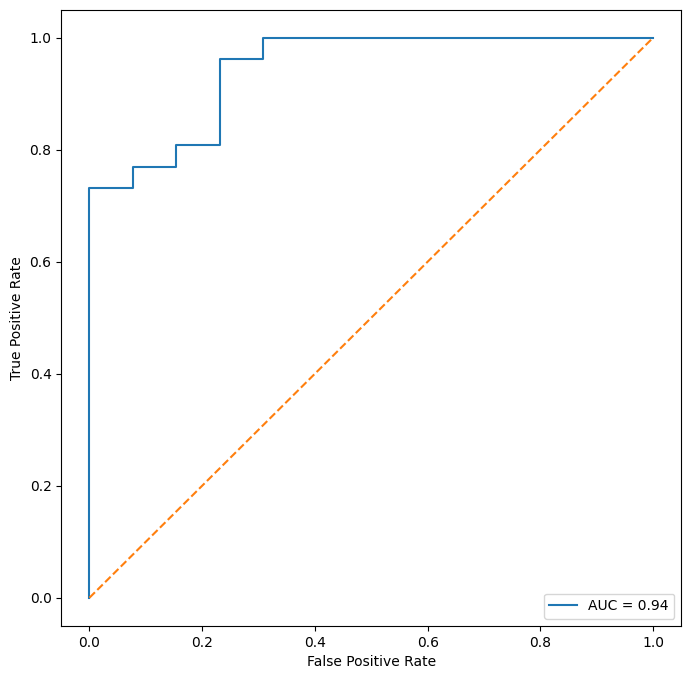

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
#plt.title('Receiver Operating Characteristic')

plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc='lower right')
plt.show()

AUC: 0.99


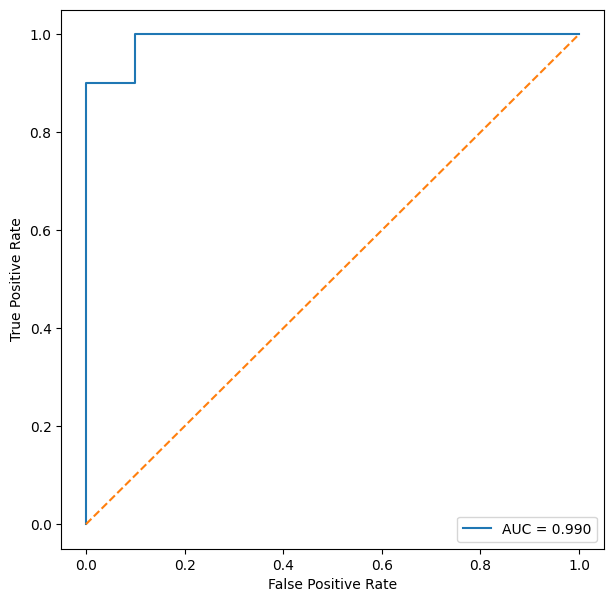

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV (YES ✅ CSV দিয়েও করা যায়)
df = pd.read_csv('/content/GSE63878_matrix_Transpose_labeled.csv')   # ← Excel হলে read_excel

# 🔹 Define X, y
X = df.drop('target', axis=1)
y = df['target']

# 🔹 Encode label (if needed)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# 🔹 Feature Selection (VERY IMPORTANT 🔥)
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=200)   # try 100,200,300
X = selector.fit_transform(X, y)

# 🔹 Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 🔹 Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# 🔹 Model (Improved SVM)
from sklearn.svm import SVC

clf = SVC(kernel='rbf', C=100, gamma=0.0001, probability=True)
clf.fit(X_train, y_train)

# 🔹 Prediction
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

# 🔹 ROC
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

# 🔹 Plot
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label='AUC = %.3f' % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

AUC: 0.9437869822485208


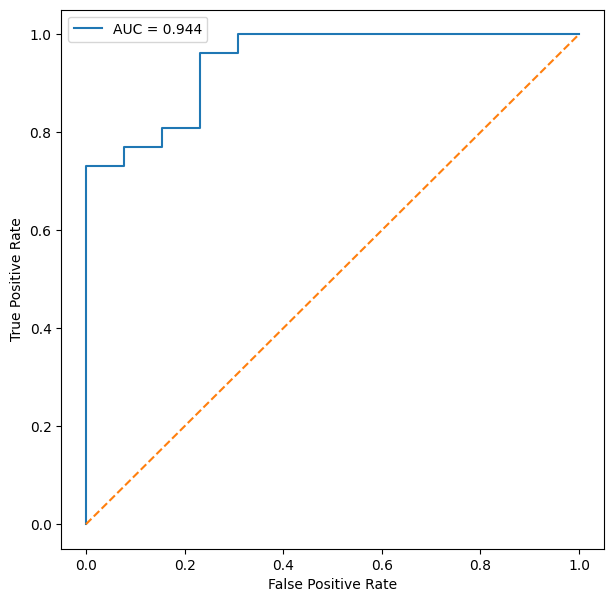

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV (YES ✅ CSV দিয়েও করা যায়)
df = pd.read_csv('/content/GSE98793_matrix_Transpose_labeled.csv')   # ← Excel হলে read_excel

# 🔹 Define X, y
X = df.drop('target', axis=1)
y = df['target']

# 🔹 Encode label (if needed)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# 🔹 Feature Selection (VERY IMPORTANT 🔥)
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=300)   # try 100,200,300
X = selector.fit_transform(X, y)

# 🔹 Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 🔹 Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# 🔹 Model (Improved SVM)
from sklearn.svm import SVC

clf = SVC(kernel='rbf', C=100, gamma=0.0001, probability=True)
clf.fit(X_train, y_train)

# 🔹 Prediction
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

# 🔹 ROC
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

# 🔹 Plot
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label='AUC = %.3f' % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()